# Term Deposit Marketing - EDA

### Data Load

In [ ]:
import pandas as pd

file_path = r"../data/term-deposit-marketing-2020.csv"
df = pd.read_csv(file_path)
# df.info()
# df.describe()
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,53,technician,married,tertiary,no,395,no,no,cellular,3,jun,107,1,no
39996,30,management,single,tertiary,no,3340,no,no,cellular,3,jun,238,3,yes
39997,54,admin,divorced,secondary,no,200,no,no,cellular,3,jun,170,1,yes
39998,34,management,married,tertiary,no,1047,no,no,cellular,3,jun,342,1,no


### Target Variable Analysis

* Check class imbalance
* Understand baseline accuracy

In [4]:
# Target distribution
target_counts = df["y"].value_counts()
target_pct = df["y"].value_counts(normalize=True) * 100

print("Counts:\n", target_counts)
print("\nPercentages:\n", target_pct.round(2))

# Baseline accuracy (majority class predictor)
baseline_acc = target_pct.max() / 100
print(f"\nBaseline Accuracy (Majority Class): {baseline_acc:.4f}")


Counts:
 y
no     37104
yes     2896
Name: count, dtype: int64

Percentages:
 y
no     92.76
yes     7.24
Name: proportion, dtype: float64

Baseline Accuracy (Majority Class): 0.9276


#### Baseline (predict always “no”):
* 92.76% accuracy

So:
* Required: ≥ 81%
* Baseline: 92.76%
* **Conclusion:** accuracy alone is useless

### Numeric Feature Summary
* Check scale
* Detect skew
* Identify outliers
* Spot unrealistic values

In [5]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_cols].describe()

,age,balance,day,duration,campaign
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,40.544600,1274.277550,16.017225,254.824300,2.882175
std,9.641776,2903.769716,8.278127,259.366498,3.239051
min,19.000000,-8019.000000,1.000000,0.000000,1.000000
25%,33.000000,54.000000,8.000000,100.000000,1.000000
50%,39.000000,407.000000,17.000000,175.000000,2.000000
75%,48.000000,1319.000000,21.000000,313.000000,3.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000


In [6]:
df[numeric_cols].skew().sort_values(ascending=False)

balance     8.259236
campaign    4.730901
duration    3.165307
age         0.436080
day         0.067930
dtype: float64

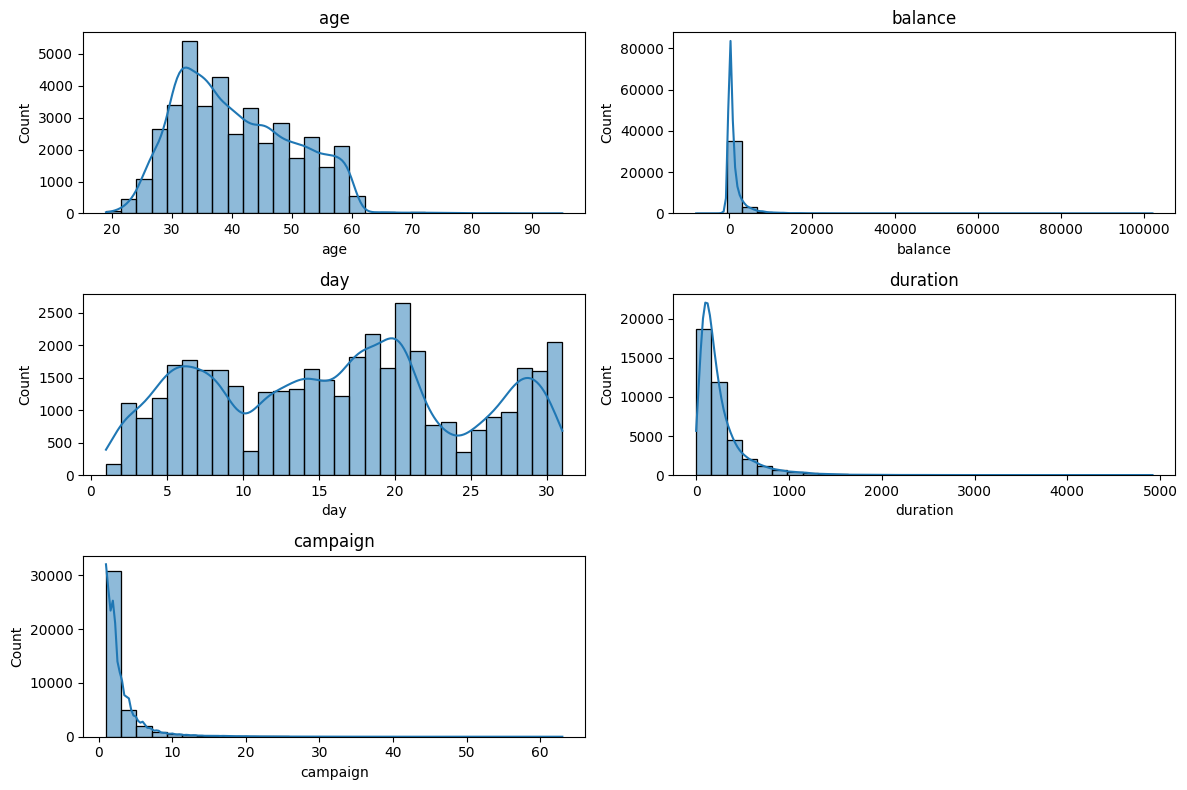

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(3,2,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


### Categorical Feature Overview
* See cardinality
* Detect “unknown” values
* Spot rare categories

In [8]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\n==== {col} ====")
    print(df[col].value_counts())


==== job ====
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64

==== marital ====
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64

==== education ====
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64

==== default ====
default
no     39191
yes      809
Name: count, dtype: int64

==== housing ====
housing
yes    24031
no     15969
Name: count, dtype: int64

==== loan ====
loan
no     33070
yes     6930
Name: count, dtype: int64

==== contact ====
contact
cellular     24914
unknown      12765
telephone     2321
Name: count, dtype: int64

==== month ====
month
may    13532
jul     6380
aug     5215
jun     4734
nov     3598
apr     2718
feb     2

C:\Users\arnav\AppData\Local\Temp\ipykernel_8604\4248142259.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [ ]:
# Unique Counts
df[categorical_cols].nunique().sort_values()

default       2
housing       2
loan          2
y             2
contact       3
marital       3
education     4
month        11
job          12
dtype: int64

### “Unknown” Category Analysis

In [12]:
for col in categorical_cols:
    if "unknown" in df[col].unique():
        print(f"\nColumn: {col}")
        print(df[df[col]=="unknown"]["y"].value_counts(normalize=True))



Column: job
y
no     0.92766
yes    0.07234
Name: proportion, dtype: float64

Column: education
y
no     0.937296
yes    0.062704
Name: proportion, dtype: float64

Column: contact
y
no     0.961065
yes    0.038935
Name: proportion, dtype: float64


### Numeric vs Target Relationship

In [13]:
for col in numeric_cols:
    print(f"\n==== {col} vs y ====")
    print(df.groupby("y")[col].mean())


==== age vs y ====
y
no     40.599208
yes    39.844959
Name: age, dtype: float64

==== balance vs y ====
y
no     1249.752533
yes    1588.495856
Name: balance, dtype: float64

==== day vs y ====
y
no     16.032072
yes    15.827003
Name: day, dtype: float64

==== duration vs y ====
y
no     221.408042
yes    682.958564
Name: duration, dtype: float64

==== campaign vs y ====
y
no     2.918688
yes    2.414365
Name: campaign, dtype: float64


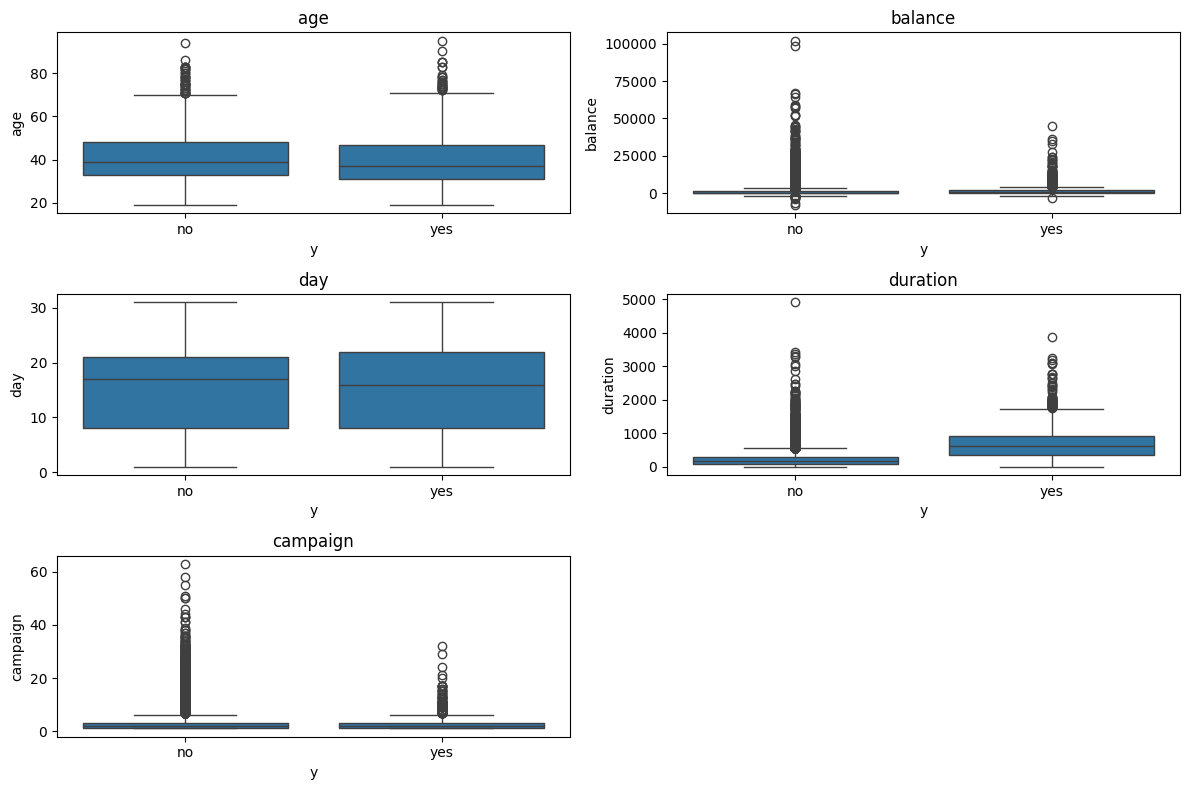

In [14]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols):
    plt.subplot(3,2,i+1)
    sns.boxplot(x="y", y=col, data=df)
    plt.title(col)
plt.tight_layout()
plt.show()


### Categorical vs Target (Conversion Rate)

In [26]:
for col in categorical_cols:
    print(f"\n==== Conversion Rate by {col} ====")
    conversion = df.groupby(col)["y"].value_counts(normalize=True)
    print(conversion)



==== Conversion Rate by job ====
job            y  
admin          no     0.921704
               yes    0.078296
blue-collar    no     0.942982
               yes    0.057018
entrepreneur   no     0.937367
               yes    0.062633
housemaid      no     0.951242
               yes    0.048758
management     no     0.917218
               yes    0.082782
retired        no     0.894920
               yes    0.105080
self-employed  no     0.920792
               yes    0.079208
services       no     0.939130
               yes    0.060870
student        no     0.843511
               yes    0.156489
technician     no     0.927466
               yes    0.072534
unemployed     no     0.913043
               yes    0.086957
unknown        no     0.927660
               yes    0.072340
Name: proportion, dtype: float64

==== Conversion Rate by marital ====
marital   y  
divorced  no     0.917249
          yes    0.082751
married   no     0.939391
          yes    0.060609
single    no  

### Month Analysis (Seasonality)

In [16]:
month_conv = df.groupby("month")["y"].apply(lambda x: (x=="yes").mean())
month_conv.sort_values(ascending=False)


month
oct    0.612500
mar    0.484496
apr    0.165931
feb    0.111063
dec    0.076923
jun    0.062104
nov    0.061145
jul    0.060188
may    0.058454
aug    0.055225
jan    0.032313
Name: y, dtype: float64

In [28]:
df.groupby("month")["y"].agg(["count", lambda x: (x=="yes").mean()])

,count,<lambda_0>
month,,
apr,2718,0.165931
aug,5215,0.055225
dec,13,0.076923
feb,2296,0.111063
jan,1176,0.032313
jul,6380,0.060188
jun,4734,0.062104
mar,258,0.484496
may,13532,0.058454


#### Some months show extremely high conversion but sample size is very small; caution required.

### Campaign Fatigue Effect

In [ ]:
campaign_analysis = df.groupby("campaign")["y"].apply(lambda x: (x=="yes").mean())
campaign_analysis.head(15)

campaign
1     0.085881
2     0.068143
3     0.070825
4     0.067334
5     0.057856
6     0.055375
7     0.050072
8     0.047529
9     0.059748
10    0.045802
11    0.065990
12    0.025974
13    0.045802
14    0.043011
15    0.048193
Name: y, dtype: float64

#### Calling more reduces probability of success.
 (Optimal calls likely 1–2.)

### Duration Strength

In [21]:
df["duration_bin"] = pd.qcut(df["duration"], q=5)
df.groupby("duration_bin")["y"].apply(lambda x: (x=="yes").mean())

duration_bin
(-0.001, 86.0]     0.003582
(86.0, 142.0]      0.016311
(142.0, 217.0]     0.027044
(217.0, 363.0]     0.043577
(363.0, 4918.0]    0.272613
Name: y, dtype: float64

#### That’s a 75x difference between lowest and highest bins.

This means:
* If call lasts long → customer already interested
* Duration reflects customer engagement

### Balance Effect

In [ ]:
df["balance_bin"] = pd.qcut(df["balance"], q=5, duplicates="drop")
df.groupby("balance_bin")["y"].apply(lambda x: (x=="yes").mean())

balance_bin
(-8019.001, 11.0]     0.054530
(11.0, 242.0]         0.059972
(242.0, 644.0]        0.069353
(644.0, 1718.0]       0.082290
(1718.0, 102127.0]    0.095899
Name: y, dtype: float64

#### Higher balance → higher likelihood.

### Correlation Matrix (Numeric Only)

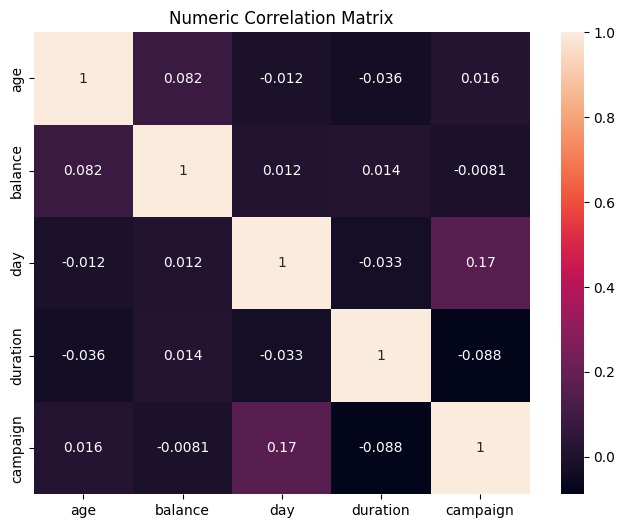

In [27]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title("Numeric Correlation Matrix")
plt.show()


### Who To Prioritize (Based on EDA Alone)
* High-probability profile:
* Student or Retired* 
* Tertiary education
* No housing loan
* No personal loan
* Higher balance
* 1–2 campaign contacts
* Cellular contact
* Certain months*

***Use with caution**: while they represent higher probability, the sample count is comparitively low to their counterparts

#### Low probability profile:
* Blue collar
* Housing loan
* Personal loan
* Many campaign attempts
* Unknown contact